#LOAD AND INITIAL EXPLORATORY DATA ANALYSIS

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

The first step in the analysis involved importing the necessary Python libraries for data manipulation, visualization, and statistical modeling.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
#Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/3MTT Assessment Folder/Multiple Linear Regression- Mini project/marketing_sales_data.csv')

The marketing dataset was then loaded into a Pandas DataFrame to understand its structure and contents.

In [10]:
df.head(5)

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377




Using the first five observations, we observed that the dataset contains both numerical and categorical variables. Specifically, TV advertising level and Influencer type are stored as categorical variables, while Radio expenditure, Social Media expenditure, and Sales are numerical.

This initial exploration provides an overview of the data and helps identify the appropriate preprocessing techniques required before building a Multiple Linear Regression model.


In [11]:
df.shape

(572, 5)

This tells us the shape or size of the dataset, they are 572 data entries (rows) and 5 features (columns)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


The dataset contains five variables with no missing observations.

* **TV:** Categorical variable representing levels of TV advertising expenditure (Low, Medium, High).
* **Radio:** Numerical variable representing Radio advertising expenditure.
* **Social Media:** Numerical variable representing Social Media advertising expenditure.
* **Influencer:** Categorical variable indicating the type of influencer used in the campaign.
* **Sales:** Numerical variable representing the resulting sales performance.

The absence of missing values indicates that no additional data cleaning procedures are required before proceeding to further analyses.


In [13]:
df.duplicated().any()

np.False_

This means there are no duplicates in the dataset,which indicating that each row represents a unique marketing campaign, reducing the risk of biased estimates resulting from repeated records.

In [14]:
df.describe(include='all')

,TV,Radio,Social Media,Influencer,Sales
count,572,572.000000,572.000000,572,572.000000
unique,3,NaN,NaN,4,NaN
top,Medium,NaN,NaN,Nano,NaN
freq,205,NaN,NaN,157,NaN
mean,NaN,17.520616,3.333803,NaN,189.296908
std,NaN,9.290933,2.238378,NaN,89.871581
min,NaN,0.109106,0.000031,NaN,33.509810
25%,NaN,10.699556,1.585549,NaN,118.718722
50%,NaN,17.149517,3.150111,NaN,184.005362
75%,NaN,24.606396,4.730408,NaN,264.500118


This provides the descriptive statistics which is the summary of the distribution and central tendency of the variables in the dataset.

Among the numerical variables, Radio expenditure averages approximately **17.52 units**, while Social Media expenditure averages approximately **3.33 units**. The average Sales value is approximately **189.30 units**, although substantial variability exists across campaigns.

For the categorical variables, **Medium** is the most frequently occurring TV expenditure category, while **Nano** influencers appear most often in the dataset.

These statistics provide useful insights into the overall characteristics of the marketing campaigns before developing predictive models.


# ENCODING CATEGORICAL VARIABLES INTO DUMMY VARIABLES


In [15]:
# Select predictors
X = df[['TV', 'Radio', 'Social Media', 'Influencer']]


# Convert categorical variables into dummy variables with numeric encoding
X_encoded = pd.get_dummies(
    X,
    columns=['TV', 'Influencer'],
    drop_first=True
).astype(int)

X_encoded.head()


,Radio,Social Media,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3,2,1,0,0,1,0
1,7,2,1,0,1,0,0
2,20,1,0,0,0,1,0
3,20,2,0,1,1,0,0
4,31,7,0,0,0,0,1


Since regression models and most machine learning algorithms require **numeric inputs**, categorical variables must be transformed into a numerical format.  
So to achieve this, I applied **one‑hot encoding** using `pd.get_dummies()`. This process created new binary (0/1) columns for each category, while dropping one category per variable to avoid the **dummy variable trap**.

After encoding, the predictors were transformed into the above structure with each dummy column takeing values **0 or 1**, indicating the presence of that category in a given observation.  
For example, if `TV_Low = 1` and `TV_Medium = 0`, the campaign used a **Low TV spend** category.  
Similarly, if `Influencer_Micro = 1`, the campaign involved a **Micro influencer**.

This transformation ensures that categorical predictors are properly represented in the regression model, enabling accurate estimation of their impact on Sales while maintaining statistical validity.


#CHECKING FOR MULTICOLLINEARITY

Before building the Multiple Linear Regression model, it is essential to check for **multicollinearity** among predictors; a condition where independent variables are highly correlated with each other.  
Multicollinearity can distort coefficient estimates and make it difficult to determine the individual effect of each predictor on Sales.

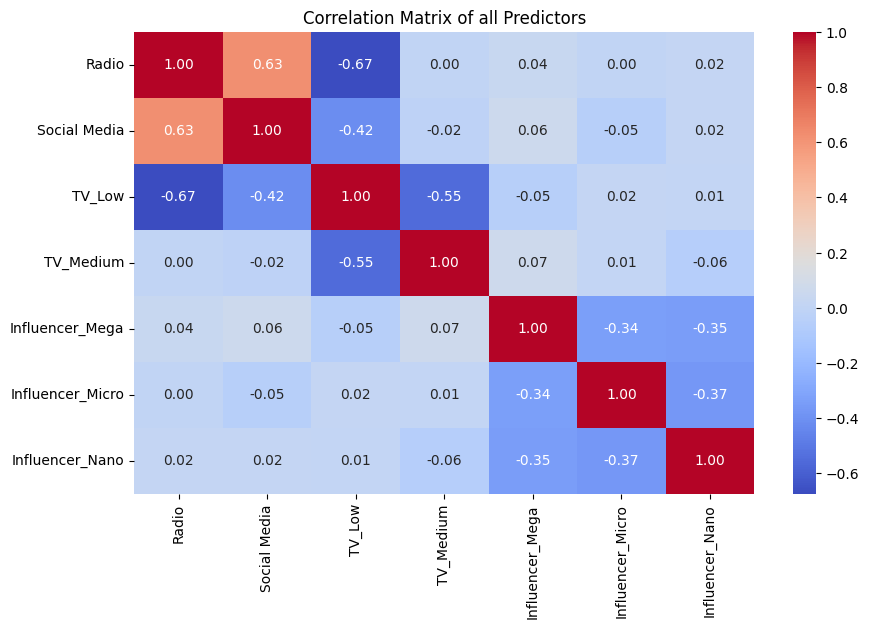

In [17]:
corr_matrix = X_encoded.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of all Predictors")
plt.show()

The heatmap above visualizes the **correlation matrix** of all encoded predictors.  

The Key Observations include:
- **Radio and Social Media** show a **moderate positive correlation (r = 0.63)**, suggesting that campaigns investing heavily in Radio also tend to spend more on Social Media.
- **Radio and TV_Low** have a **strong negative correlation (r = -0.67)**, indicating that lower TV spending levels are often associated with higher Radio expenditure.
- **TV_Low and TV_Medium** are **moderately negatively correlated (r = -0.55)**, which is expected since they represent different categories of the same variable.
- **Influencer categories (Mega, Micro, Nano)** show **moderate negative correlations (r ≈ -0.34 to -0.37)** among themselves, reflecting mutual exclusivity; a campaign typically uses one influencer type at a time.
- Other relationships, such as between **Social Media and TV_Medium (r = -0.02)** or **Radio and Influencer_Mega (r = 0.04)**, are weak, indicating minimal overlap.

None of the correlations exceed **|0.8|**, which is a common threshold for severe multicollinearity. However, the moderate correlations among TV categories and between Radio and Social Media warrant further investigation using **Variance Inflation Factor (VIF)** to confirm that multicollinearity is not problematic.

 # VARIANCE INFLATION FACTOR (VIF)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant
X_vif = sm.add_constant(X_encoded)

# Calculate VIF
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_data

,Variable,VIF
0,const,30.641148
1,Radio,3.479949
2,Social Media,1.655001
3,TV_Low,4.085009
4,TV_Medium,2.237814
5,Influencer_Mega,1.593084
6,Influencer_Micro,1.618716
7,Influencer_Nano,1.626784


 **Key Insights**:
- No predictor exceeds the critical **threshold of 10**, meaning multicollinearity is not severe.  
- **Radio (VIF = 3.48)** and **TV_Low (VIF = 4.09)** show the highest inflation, consistent with the moderate correlations observed earlier.  
- **Social Media and Influencer categories** all have VIF values close to 1.6, indicating minimal overlap with other predictors.  
- The **constant term (VIF = 30.64)** is expected to be high and does not affect model validity.

Each advertising channel provides **unique explanatory power** for predicting Sales; while Radio and TV spending categories overlap somewhat, they are not redundant, both can remain in the model. `Social Media` and `Influencer` types are statistically independent enough to justify inclusion.  

 Overall, the regression model is robust against multicollinearity, ensuring that coefficient estimates can be interpreted reliably for budget allocation decisions.


#MODEL BUILDING

##Train-Test Split

In [23]:
X = X_encoded
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


I split the dataset into training and test sets (80/20). This ensures the model is trained on one portion of the data and evaluated on unseen data, helping to measure generalization performance.

In [35]:
# Add a constant to include the intercept
X_train_const = sm.add_constant(X_train)

# Build and fit the OLS model
ols_model = sm.OLS(y_train, X_train_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     615.9
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          1.14e-225
Time:                        13:20:08   Log-Likelihood:                -2165.8
No. Observations:                 457   AIC:                             4348.
Df Residuals:                     449   BIC:                             4381.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              216.3724      7.366  

The model achieved an **Adjusted R-squared of 0.904**, meaning that after accounting for the number of predictors, the regression explains about **90.4% of the variation in Sales**. This high value indicates that the model fits the data very well and remains robust even with multiple predictors included.

and as for the individual predictor p-values:
- **Radio (p < 0.001)** : Statistically significant. Radio expenditure has a reliable positive effect on Sales.  
- **Social Media (p = 0.766)** : Not significant. Social Media spend does not show a consistent impact on Sales.  
- **TV_Low (p < 0.001)** : Statistically significant. Campaigns with Low TV spend are associated with significantly lower Sales compared to High TV spend (baseline).  
- **TV_Medium (p < 0.001)** : Statistically significant. Medium TV spend also results in lower Sales compared to High TV spend.  
- **Influencer_Mega (p = 0.773)**, **Influencer_Micro (p = 0.598)**, **Influencer_Nano (p = 0.903)** : None are statistically significant. Influencer type does not reliably affect Sales in this dataset.

The model is **strong overall** (Adjusted R² = 0.904).  **TV and Radio** are the key drivers of Sales, with statistically significant effects. **Social Media and Influencer categories** do not contribute meaningfully to Sales prediction and could be excluded from ROI-focused models.

 # Diagnostic plots to Validate Linearity, Normality, and Homoscedasticity

To ensure the validity of the Multiple Linear Regression model, three key assumptions were tested using diagnostic plots: **Linearity**, **Normality**, and **Homoscedasticity**. These checks confirm whether the model’s residuals behave as expected for reliable inference; so before then we would have to fetch the model's residual.

In [34]:
# Getting the Residuals
residuals = ols_model.resid
fitted = ols_model.fittedvalues

## 1. Linearity

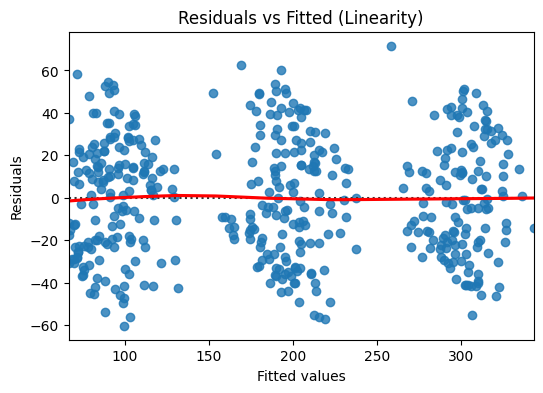

In [36]:
plt.figure(figsize=(6,4))
sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color':'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity)")
plt.show()


This plot examines whether the relationship between predictors and the dependent variable is linear.

- The red line represents the mean of residuals across fitted values.
- Ideally, residuals should be randomly scattered around zero without visible patterns.

**Observation:**
- The residuals are centered around zero with no strong curvature, suggesting that the linearity assumption is reasonably satisfied.
- Slight clustering around fitted values (~100, ~200, ~300) may indicate group effects from categorical TV levels, but overall the trend remains stable.

**Interpretation:**
The model captures the linear relationship between predictors and Sales effectively, with no major violations of linearity.

## 2. Normality


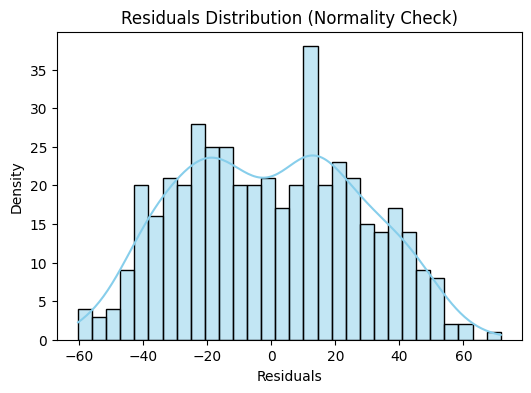

In [37]:
# Histogram with KDE (bell curve shape)
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30, color="skyblue")
plt.title("Residuals Distribution (Normality Check)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

This histogram with a density curve assesses whether residuals follow a normal distribution.

**Observation:**
- The residuals are approximately symmetric around zero.
- The distribution shows mild deviations from perfect normality, with a slightly peaked center and light tails.

**Interpretation:**
Residuals are close to normal, satisfying the normality assumption required for valid hypothesis testing and confidence intervals. Minor deviations are acceptable given the large sample size (n = 457).

## 3. Homoscedasticity

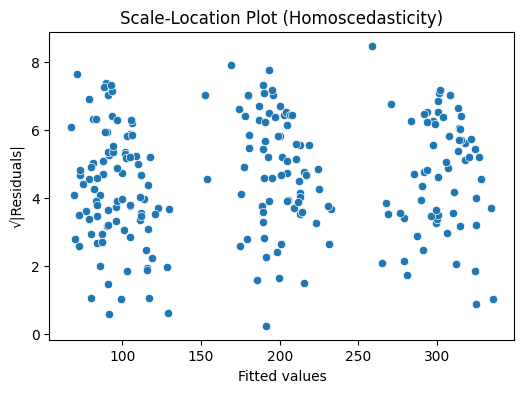

In [38]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=abs(residuals**0.5))
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Homoscedasticity)")
plt.show()

This plot tests whether residuals have constant variance across fitted values (homoscedasticity).

**Observation:**
- The spread of √|Residuals| appears fairly uniform across fitted values.
- No clear funnel shape or systematic increase/decrease in variance is visible.

**Interpretation:**
The variance of residuals remains consistent across predicted Sales values, confirming the homoscedasticity assumption. This means the model’s error terms are stable and unbiased across different levels of predicted Sales.


#  COEFFICIENT INTERPRETATION IN CONTEXT



Each regression coefficient represents the expected change in **Sales** for a one‑unit increase in a given predictor, **holding all other variables constant**.  
This allows us to isolate the individual effect of each marketing channel on Sales.

#### Key Interpretations:

- **Radio (coef = 2.9773, p < 0.001)**  
  For every additional unit spent on Radio advertising, **Sales increase by approximately 2.98 units**, assuming TV, Social Media, and Influencer spending remain constant.  
  This confirms Radio has a strong, statistically significant positive impact on Sales.

- **Social Media (coef = 0.2231, p = 0.766)**  
  A one‑unit increase in Social Media spend is associated with only **0.22 units increase in Sales**, but this effect is **not statistically significant**.  
  This suggests Social Media spending does not reliably drive Sales in this dataset.

- **TV_Low (coef = -149.4148, p < 0.001)**  
  Campaigns with **Low TV spend** generate about **149 fewer Sales units** compared to campaigns with **High TV spend** (baseline), holding other factors constant.  
  This indicates that reducing TV investment substantially lowers Sales performance.

- **TV_Medium (coef = -71.4997, p < 0.001)**  
  Campaigns with **Medium TV spend** produce roughly **71 fewer Sales units** than High TV spend campaigns.  
  This reinforces that higher TV investment yields stronger returns.

- **Influencer_Mega (coef = 1.1380, p = 0.773)**  
  Using Mega influencers increases Sales by about **1.14 units**, but the effect is **not significant**.  
  Their impact on direct Sales appears negligible.

- **Influencer_Micro (coef = 1.9676, p = 0.598)**  
  Micro influencers show a small, non‑significant increase of **1.97 units** in Sales.  
  Their contribution is statistically weak.

- **Influencer_Nano (coef = -0.4551, p = 0.903)**  
  Nano influencers are associated with a minor decrease of **0.46 units** in Sales, also **not significant**.

#### Summary
- **TV and Radio** are the only channels with statistically significant effects on Sales.  
- **Social Media and Influencer types** do not show meaningful changes in Sales when their spending increases.  
- Holding other variables constant, increasing **TV and Radio budgets** is the most effective strategy for boosting Sales.

#### Business Implication
For every additional unit of Radio spend, Sales rise by nearly 3 units, while maintaining high TV investment prevents large drops in performance.  
This evidence supports prioritizing **TV and Radio** in marketing budgets to maximize ROI.



# RECOMMENDATION


Based on the regression analysis and diagnostic checks, the following insights guide marketing budget allocation:

- **TV Advertising**  
  Campaigns with **High TV spend** consistently outperform those with Low or Medium spend.  
  Reducing TV investment leads to substantial drops in Sales (−149 units for Low, −71 units for Medium).  
  **Recommendation:** Maintain or increase High TV spend as the primary driver of Sales growth.

- **Radio Advertising**  
  Radio expenditure has a statistically significant positive effect (coef ≈ 2.98, p < 0.001).  
  Each additional unit of Radio spend increases Sales by nearly 3 units.  
  **Recommendation:** Continue investing in Radio as a complementary channel to TV.

- **Social Media**  
  The effect of Social Media spend is small and statistically insignificant (p = 0.766).  
  **Recommendation:** Reevaluate Social Media strategy, it may be better suited for brand awareness or engagement rather than direct ROI.

- **Influencer Marketing**  
  Mega, Micro, and Nano influencers show no significant impact on Sales (p-values > 0.59).  
  **Recommendation:** Limit influencer spend in ROI-focused campaigns; consider reallocating toward channels with proven sales impact.


**Final Strategic Guidance**:
- **Prioritize High TV spend** as the cornerstone of marketing campaigns.  
- **Support with Radio advertising**, which reliably boosts Sales.  
- **Reallocate budget away from Social Media and Influencers** for direct sales objectives, while reserving them for non-sales goals like engagement or brand visibility.  

This evidence-based allocation ensures maximum return on investment by focusing resources on the channels that demonstrably drive Sales.
